# Modular Gradient Descent – Linear Regression (2-point dataset)

**Objective**  
Fit a line y = m·x + b to points (1, 3) and (3, 6) using gradient descent,  
but with **modular design** and **SciPy minimize** for optimization (as per instructions).

**Improvements from previous version**  
- Loss function and gradient are isolated → easy to change error function  
- Uses `scipy.optimize.minimize` with analytical Jacobian (gradient)  
- Callback prints progress for transparency (first few iterations)  
- Side-by-side plots for parameters and MSE

Dataset: (x=1, y=3), (x=3, y=6)  
Initial guess: m = -1, b = 1  

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ── Data ─────────────────────────────────────────────────────────
x = np.array([1.0, 3.0])
y = np.array([3.0, 6.0])
n = len(x)

print("Dataset loaded:")
print(f"  x = {x}")
print(f"  y = {y}")

Dataset loaded:
  x = [1. 3.]
  y = [3. 6.]


In [2]:
# ── Loss Function (MSE) ──────────────────────────────────────────
def mse_loss(params, x, y):
    """Mean Squared Error: (1/n) Σ (y - (m x + b))^2"""
    m, b = params
    y_hat = m * x + b
    return np.mean((y - y_hat) ** 2)


# ── Gradient (Jacobian) of the loss ──────────────────────────────
def mse_gradient(params, x, y):
    """∂J/∂m and ∂J/∂b for MSE"""
    m, b = params
    y_hat = m * x + b
    errors = y_hat - y
    grad_m = (2 / n) * np.sum(x * errors)
    grad_b = (2 / n) * np.sum(errors)
    return np.array([grad_m, grad_b])


print("Loss and gradient functions defined (modular).")
print("You can replace mse_loss & mse_gradient with any other differentiable loss.")

Loss and gradient functions defined (modular).
You can replace mse_loss & mse_gradient with any other differentiable loss.


In [7]:
# ── Callback: print progress during optimization ─────────────────
iteration = 0
m_hist, b_hist, mse_hist = [], [], []

def print_progress(params):
    global iteration
    iteration += 1
    m, b = params
    current_mse = mse_loss(params, x, y)

    m_hist.append(m)
    b_hist.append(b)
    mse_hist.append(current_mse)

    # Print only first 5 steps
    if iteration <= 5:
        print(f"Iter {iteration:2d} | m = {m:.4f} | b = {b:.4f} | MSE = {current_mse:.4f}")
        y_hat = m * x + b
        print(f"   Predictions: {y_hat[0]:.2f} vs 3 | {y_hat[1]:.2f} vs 6")

In [8]:
# ── Optimization with SciPy minimize ─────────────────────────────
initial_params = np.array([-1.0, 1.0])

print("Starting optimization...\n")

res = minimize(
    fun=mse_loss,
    x0=initial_params,
    args=(x, y),
    jac=mse_gradient,               # analytical gradient → faster & more accurate
    method='BFGS',                  # good default for smooth problems
    callback=print_progress,
    options={'disp': False, 'maxiter': 50}
)

print("\n" + "═"*50)
print("Optimization finished!")
print(f"Success: {res.success}")
print(f"Final m = {res.x[0]:.4f}, b = {res.x[1]:.4f}")
print(f"Final MSE = {res.fun:.6f}")
print(f"Message: {res.message}")

Starting optimization...

Iter  1 | m = -0.0646 | b = 1.3811 | MSE = 12.9991
   Predictions: 1.32 vs 3 | 1.19 vs 6
Iter  2 | m = 1.3793 | b = 1.7914 | MSE = 0.0171
   Predictions: 3.17 vs 3 | 5.93 vs 6
Iter  3 | m = 1.4214 | b = 1.6915 | MSE = 0.0074
   Predictions: 3.11 vs 3 | 5.96 vs 6
Iter  4 | m = 1.5000 | b = 1.5000 | MSE = 0.0000
   Predictions: 3.00 vs 3 | 6.00 vs 6
Iter  5 | m = 1.5000 | b = 1.5000 | MSE = 0.0000
   Predictions: 3.00 vs 3 | 6.00 vs 6

══════════════════════════════════════════════════
Optimization finished!
Success: True
Final m = 1.5000, b = 1.5000
Final MSE = 0.000000
Message: Optimization terminated successfully.


In [9]:
# ── Final predictions ────────────────────────────────────────────
m_opt, b_opt = res.x
y_pred = m_opt * x + b_opt

print("\nFinal results:")
print(f"  Predicted y(1) = {y_pred[0]:.3f} (target 3)")
print(f"  Predicted y(3) = {y_pred[1]:.3f} (target 6)")
print(f"  MSE = {res.fun:.6f}")


Final results:
  Predicted y(1) = 3.000 (target 3)
  Predicted y(3) = 6.000 (target 6)
  MSE = 0.000000


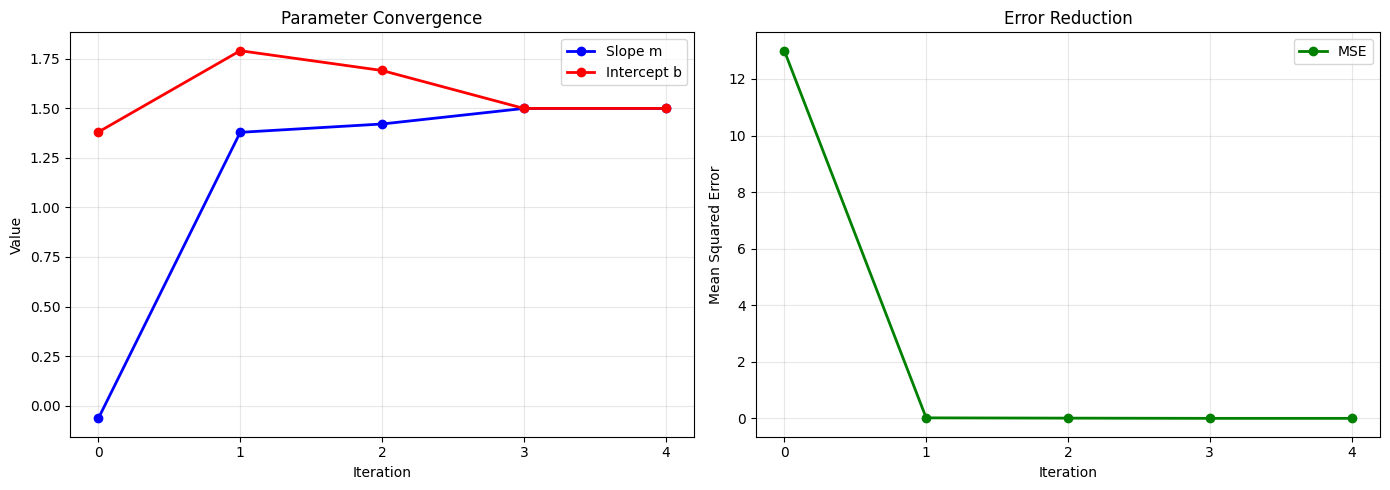

In [10]:
# ── Visualization ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iters = np.arange(len(m_hist))

ax1.plot(iters, m_hist, 'b-o', label='Slope m', linewidth=2, markersize=6)
ax1.plot(iters, b_hist, 'r-o', label='Intercept b', linewidth=2, markersize=6)
ax1.set_title('Parameter Convergence')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Value')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xticks(iters)

ax2.plot(iters, mse_hist, 'g-o', label='MSE', linewidth=2, markersize=6)
ax2.set_title('Error Reduction')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Mean Squared Error')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xticks(iters)

plt.tight_layout()
plt.show()